In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv('CHURN_CREDIT_MOD14.csv') # Carregar o arquivo tratado
df.head(10)

,Credit_Score,Pais,Genero,Idade,Tempo_Credito,Balanco,Qtd_Produtos,Possui_Cartao,Membro_Ativo,Salario_Anual,Churn
0,677,SPAIN,Male,18.0,5,134796.87,2,1.0,0.0,10787603.0,False
1,644,SPAIN,Female,18.0,7,0.00,1,0.0,1.0,10787603.0,False
2,641,SPAIN,Male,18.0,1,0.00,2,0.0,1.0,10787603.0,False
3,826,SPAIN,Male,18.0,2,0.00,2,0.0,1.0,10787603.0,False
4,774,SPAIN,Female,18.0,1,185891.54,1,1.0,0.0,10787603.0,False
5,688,SPAIN,Female,18.0,2,0.00,2,1.0,0.0,10787603.0,False
6,803,SPAIN,Male,18.0,6,0.00,1,0.0,0.0,10787603.0,True
7,578,SPAIN,Female,18.0,8,71843.15,2,0.0,1.0,10787603.0,False
8,598,SPAIN,Male,18.0,6,0.00,2,0.0,1.0,10787603.0,False
9,624,SPAIN,Female,18.0,6,0.00,2,0.0,1.0,10787603.0,False


Método describe da um resumao das estatísticas

In [3]:
df.describe()



,Credit_Score,Idade,Tempo_Credito,Balanco,Qtd_Produtos,Possui_Cartao,Membro_Ativo,Salario_Anual
count,99708.000000,99708.000000,99708.000000,99708.000000,99708.000000,99708.000000,99708.000000,9.970800e+04
mean,656.504283,38.144095,5.027992,55594.901735,1.553777,0.755406,0.497422,1.061229e+07
std,80.280520,8.818943,2.806751,62789.275840,0.547746,0.429849,0.499996,3.350758e+06
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.158000e+03
25%,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,1.078760e+07
50%,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,1.078760e+07
75%,710.000000,42.000000,7.000000,119859.537500,2.000000,1.000000,1.000000,1.078760e+07
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,3.819017e+07


ANALISE UNIVARIADA DE ALGUMAS VARIÁVEIS(COLUNAS)

Variáveis numéricas:

In [4]:
(df['Balanco'] == 0).sum() # Contar quantos clientes tem o balanço igual a zero

np.int64(54033)

In [5]:
(df['Balanco'] == 0).mean() * 100 # A porcentagem de clientes com balanço igual a zero 

np.float64(54.19123841617524)

Boxplot da coluna

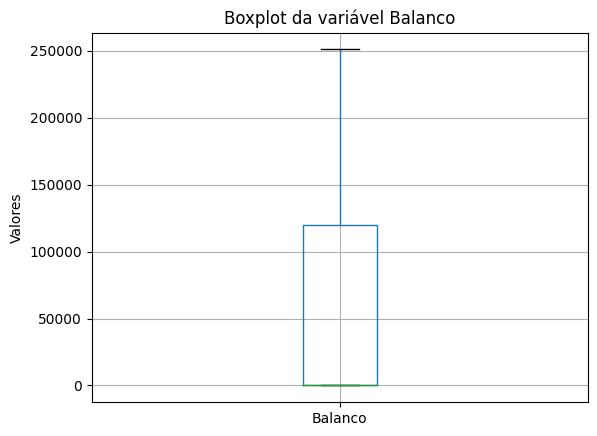

In [6]:
df.boxplot(column='Balanco') 
plt.title('Boxplot da variável Balanco')
plt.ylabel('Valores')
plt.show()

Selecionar os valores da coluna balanço diferentes de 0 e colocar em um novo df

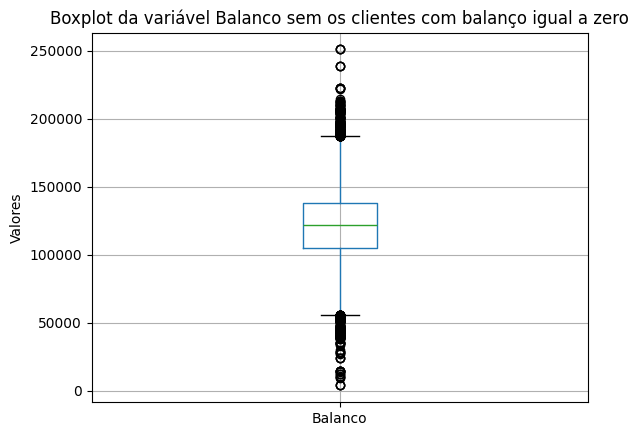

In [7]:
df_no_zero = df[df['Balanco'] != 0] # Criar um novo dataframe sem os clientes com balanço igual a zero
df_no_zero.boxplot(column='Balanco')
plt.title('Boxplot da variável Balanco sem os clientes com balanço igual a zero')
plt.ylabel('Valores')
plt.show()

# É possível notar muitos outliers na coluna

Observando a coluna Qtd_Produtos

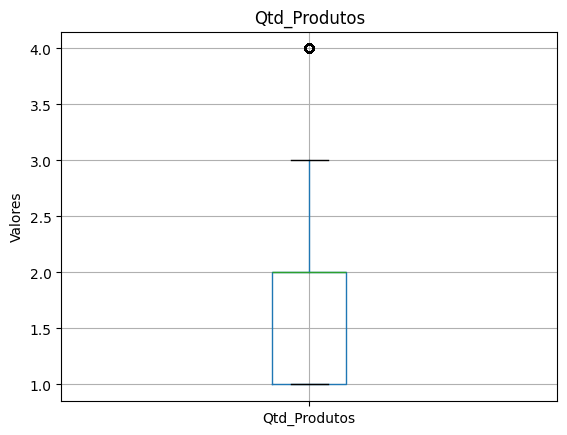

In [8]:
df.boxplot(column='Qtd_Produtos')
plt.title('Qtd_Produtos')
plt.ylabel('Valores')
plt.show()

# Não é muito correto considerar o valor 4 como outlier, pois é os valores da coluna são bem restritos




Coluna Tempo de Crédito(parece estar bem distribuida)

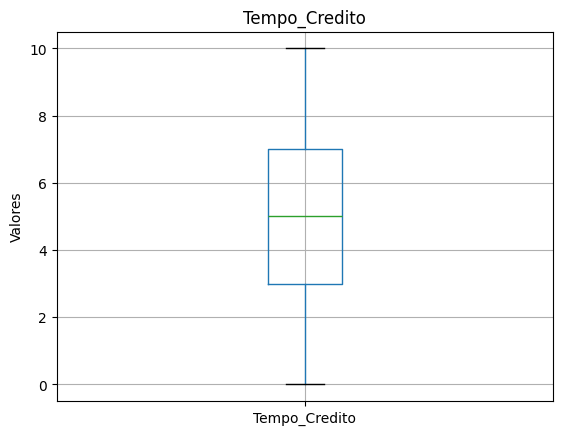

In [9]:
df.boxplot(column='Tempo_Credito')
plt.title('Tempo_Credito')
plt.ylabel('Valores')
plt.show()

Variáveis Booleanas:

- Possui_Cartao

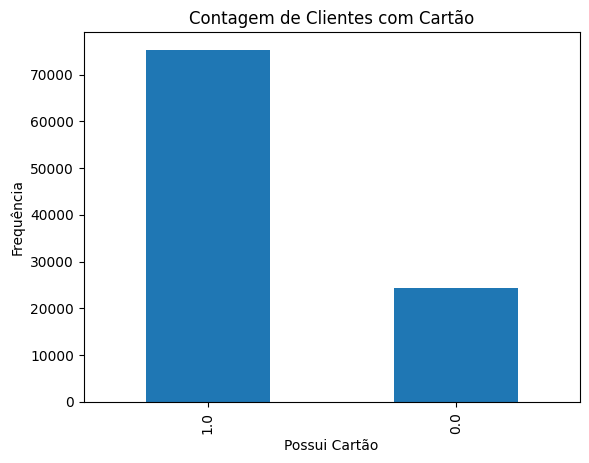

In [10]:
# Contagem dos valores da coluna 'Possui_Cartao'
contagem_cartao = df['Possui_Cartao'].value_counts()

# Calculando porcentagem 
porcentagem_cartao = (contagem_cartao / contagem_cartao.sum()) * 100
ax = contagem_cartao.plot(kind='bar')
plt.title('Contagem de Clientes com Cartão')
plt.xlabel('Possui Cartão')
plt.ylabel('Frequência')
plt.show()


In [11]:
# Contando as ocorrências
contagem_cartao = df['Possui_Cartao'].value_counts()

#Calculando a porcentagem
(contagem_cartao / contagem_cartao.sum()) * 100

Possui_Cartao
1.0    75.540578
0.0    24.459422
Name: count, dtype: float64

- Membro_Ativo

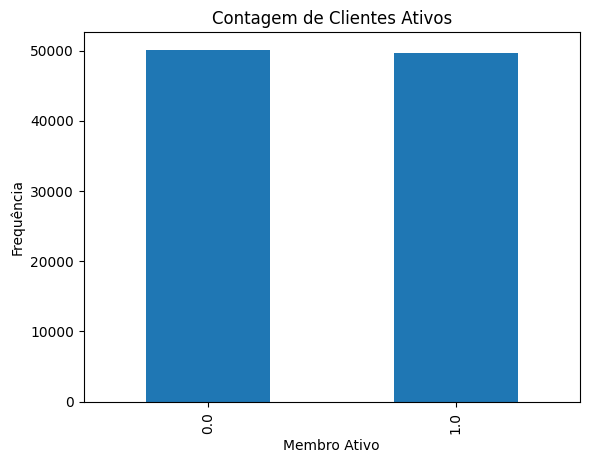

In [12]:
contagem_membro = df['Membro_Ativo'].value_counts()

porcentagem_membro = (contagem_membro / contagem_membro.sum()) * 100
ax = contagem_membro.plot(kind='bar')
plt.title('Contagem de Clientes Ativos')
plt.xlabel('Membro Ativo')
plt.ylabel('Frequência')
plt.show()

In [13]:
contagem_membro = df['Membro_Ativo'].value_counts()
(contagem_membro / contagem_membro.sum()) * 100

Membro_Ativo
0.0    50.257753
1.0    49.742247
Name: count, dtype: float64

- Churn

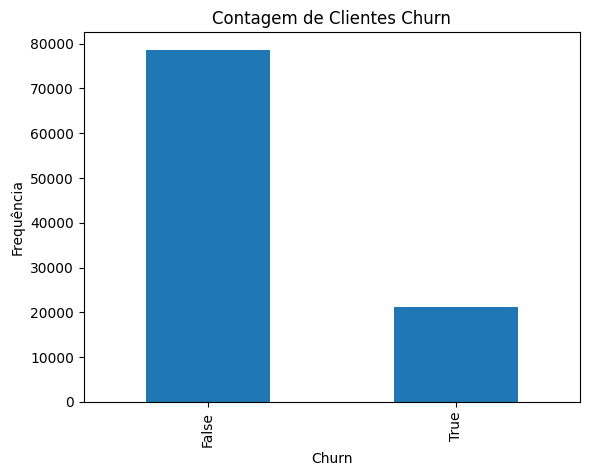

In [14]:
contagem_churn = df['Churn'].value_counts()

porcentagem_churn = (contagem_churn / contagem_churn.sum()) * 100
ax = contagem_churn.plot(kind='bar')
plt.title('Contagem de Clientes Churn')
plt.xlabel('Churn')
plt.ylabel('Frequência')
plt.show()

In [15]:
contagem_churn = df['Churn'].value_counts()
(contagem_churn / contagem_churn.sum()) * 100

Churn
False    78.854254
True     21.145746
Name: count, dtype: float64

Variáveis Categóricas: 

- País

C:\Users\samco\AppData\Local\Temp\ipykernel_15040\4095660625.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 5, f'{porcentagem[i]:.2f}%', ha='center')


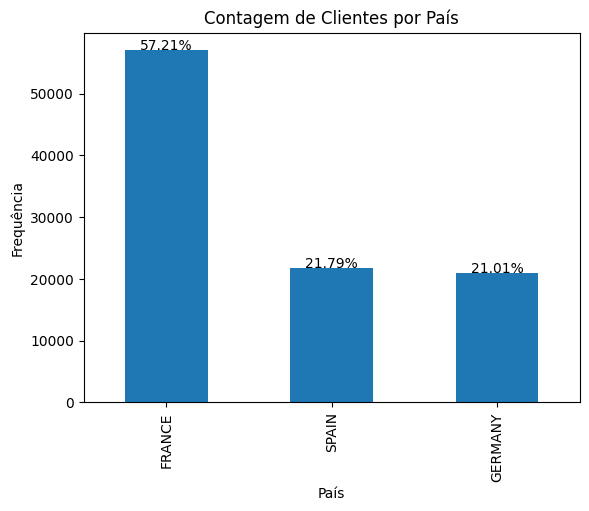

In [16]:
# Calculando as porcentagens
contagem = df['Pais'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100

ax = contagem.plot(kind='bar')

# Adicionando porcentagens nas barras
for i, v in enumerate(contagem):
    ax.text(i, v + 5, f'{porcentagem[i]:.2f}%', ha='center')
plt.title('Contagem de Clientes por País')
plt.xlabel('País')
plt.ylabel('Frequência')
plt.show()


- Genero

C:\Users\samco\AppData\Local\Temp\ipykernel_15040\3191874303.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 5, f'{porcentagem[i]:.2f}%', ha='center')


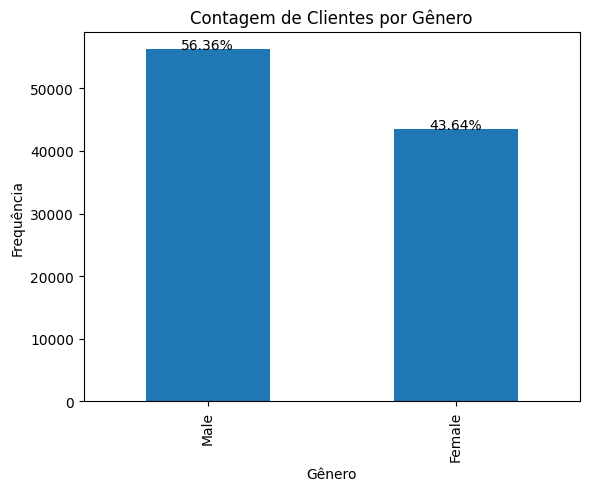

In [17]:
# Calculando as porcentagens
contagem = df['Genero'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100

ax = contagem.plot(kind='bar')

# Adicionando porcentagens nas barras
for i, v in enumerate(contagem):
    ax.text(i, v + 5, f'{porcentagem[i]:.2f}%', ha='center')
plt.title('Contagem de Clientes por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Frequência')
plt.show()


Detectando outliers

In [ ]:
df_no_zero = df[df['Balanco'] != 0] # Criar um novo dataframe sem os clientes com balanço igual a zero

fig = px.box(df_no_zero, y='Balanco', title='Boxplot de Balanco(sem clientes com balanço igual a zero)', labels={'Balanco': 'Valores'})
fig.show()

Verificando valores acima de 186000

In [19]:
df[df['Balanco'] > 186000]

,Credit_Score,Pais,Genero,Idade,Tempo_Credito,Balanco,Qtd_Produtos,Possui_Cartao,Membro_Ativo,Salario_Anual,Churn
315,673,SPAIN,Female,23.0,1,186813.76,2,0.0,1.0,10787603.0,False
939,498,SPAIN,Male,26.0,1,198113.86,1,1.0,0.0,10787603.0,False
1142,771,SPAIN,Female,26.0,5,193354.86,2,1.0,0.0,10787603.0,False
1174,564,SPAIN,Male,26.0,3,187294.46,1,0.0,1.0,10787603.0,False
1866,850,SPAIN,Male,28.0,9,206014.94,2,0.0,1.0,10787603.0,False
...,...,...,...,...,...,...,...,...,...,...,...
97828,550,FRANCE,Female,58.0,4,207034.96,4,1.0,0.0,15769476.0,True
98106,662,FRANCE,Female,59.0,7,187911.55,1,0.0,0.0,235315.0,True
98695,539,FRANCE,Male,62.0,4,186825.57,1,1.0,1.0,12782525.0,True
98869,682,FRANCE,Male,63.0,4,207034.96,1,0.0,0.0,15739757.0,True


In [20]:
print("Porcentagem de registros onde 'balanco' > 186000: ", (len(df[df['Balanco'] > 186000]) / len(df)) * 100)

Porcentagem de registros onde 'balanco' > 186000:  0.2306735668151001


Exemplo de como substituiria os outliers pela mediana:

In [21]:
df_exemplo = df.copy() # Copia para nao modificar o original

# Criando os quartis do boxplot para remover aqueles que estão fora
Q1 = df_exemplo['Balanco'].quantile(0.25)
Q3 = df_exemplo['Balanco'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Criar um novo dataframe sem os outliers
df_no_outliers = df_exemplo[(df_exemplo['Balanco'] >= limite_inferior) & (df_exemplo['Balanco'] <= limite_superior)] 

# Calculando a mediana dos dados sem os valores maiores que 186000
mediana_no_outliers = df_no_outliers['Balanco'].median()

# Substituindo os valores maiores que 186000 pela mediana no novo df
df_exemplo.loc[df_exemplo['Balanco'] > 186000, 'Balanco'] = mediana_no_outliers

Variável Qtd_Produtos

In [22]:
fig = px.box(df, y= 'Qtd_Produtos', title='Boxplot de Qtd_Produtos', labels={'Qtd_Produtos': 'Valores'})
fig.show()

In [23]:
df['Qtd_Produtos'].value_counts(normalize=True) * 100

Qtd_Produtos
2    51.003931
1    46.962129
3     1.728046
4     0.305893
Name: proportion, dtype: float64

BIVARIADA

Perguntas:
- Mulheres sao mais propensas a churn que homens?
- Os Clientes de que país costumam a contratar mais produtos?
- Em qual país temos tido maior % de churn?
- Qual idade tendemos a ter mais churn?

In [24]:
# Calcular porcentagem de cada categoria
df_grouped = df.groupby(['Churn', 'Genero']).size().reset_index(name='count')
total_por_churn = df_grouped.groupby('Churn')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_churn) * 100

# Criar o gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Churn', y='percent', color='Genero', barmode = 'stack', labels={'percent': 'Porcentagem', 'Churn': 'Churn', 'Genero': 'Gênero'})

# Layout
fig.update_layout(
    title='Distribuição de Churn por Gênero',
    yaxis_title='Porcentagem',
    legend_title='Gênero'
)
fig.show()

In [25]:
# Calcular porcentagem de cada categoria
df_grouped = df.groupby(['Churn', 'Pais']).size().reset_index(name='count')
total_por_churn = df_grouped.groupby('Churn')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_churn) * 100

fig = px.bar(df_grouped, x='Churn', y='percent', color='Pais', barmode = 'stack', labels={'percent': 'Porcentagem', 'Churn': 'Churn', 'Pais': 'País'})

# Layout
fig.update_layout(
    title='Distribuição de Churn por País',
    yaxis_title='Porcentagem',
    legend_title='País'
)
fig.show()

In [26]:
# Calculando a mediana de produtos por pais
media_produtos_pais = df.groupby('Pais')['Qtd_Produtos'].median().reset_index()

# Criar gráfico de barras
fig = px.bar(media_produtos_pais, x='Pais', y='Qtd_Produtos', title='Media de Produtos por País', labels={'Qtd_Produtos': 'Media de Produtos', 'Pais': 'País'})
fig.show()

In [27]:
media = df.groupby('Churn')['Idade'].mean().reset_index()

fig = px.bar(media, x='Churn', y='Idade', title='Média de Idade por Churn', labels={'Idade': 'Média de Idade', 'Churn': 'Churn'})
fig.show()

In [28]:
fig = px.histogram(df, x='Churn', color='Membro_Ativo', barmode='stack')
fig.update_layout(
    title='Distribuição de Churn por Membro Ativo',
    xaxis_title='Churn',
    yaxis_title='Contagem',
    legend_title='Membro Ativo'
)   
fig.show()

In [29]:
mediana = df.groupby('Churn')['Salario_Anual'].median().reset_index()
fig = px.bar(mediana, x='Churn', y='Salario_Anual', title='MMediana de Salário Anual por Churn', labels={'Salario_Anual': 'MMediana de Salário Anual', 'Churn': 'Churn'})
fig.show()

In [30]:
medianaa = df.groupby('Pais')['Salario_Anual'].median().reset_index()
fig = px.bar(medianaa, x='Pais', y='Salario_Anual', title='Mediana de Salário Anual por País')
fig.show()


In [31]:
media_salario_por_idade = df.groupby('Idade')['Salario_Anual'].mean().reset_index()
fig = px.line(media_salario_por_idade, x='Idade', y='Salario_Anual', title='Média de Salário Anual por Idade', labels={'Salario_Anual': 'Média de Salário Anual', 'Idade': 'Idade'})
fig.show()

Insights retirados da analise bivariada:

- Mulheres tem maior propensao a abandonar o servico
- Alemanha é o principal país onde se perde clientes
- Clientes mais velhos são mais propensos a deixar o serviço
- Membros ativos abandonam menos a marca
- Clientes franceses tem uma média salarial superior
- Clientes mais velhos tem média salarial maior